In [7]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [8]:
df = pd.read_excel("prosper_ann_cleaned.xlsx")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (43366, 12)


,StatedMonthlyIncome,DebtToIncomeRatio,CreditScoreRangeLower,BankcardUtilization,AvailableBankcardCredit,RevolvingCreditBalance,AmountDelinquent,DelinquenciesLast7Years,LoanOriginalAmount,BorrowerRate,RealizedInterestRatio,NetPrincipalLossRatio
0,3083.333333,0.17,640,0.00,1500,0,472,4,9425,0.1580,0.209140,0.000000
1,1666.666667,0.27,640,0.32,2580,1220,2224,1,1000,0.1325,0.011650,0.000000
2,5500.000000,0.49,700,0.97,178,9103,0,0,4000,0.3177,0.077845,0.947562
3,3750.000000,0.09,620,0.08,1366,134,5200,5,3000,0.2075,0.353683,0.000000
4,2500.000000,0.39,680,0.84,607,7975,0,0,2000,0.2419,0.059140,0.941135


In [9]:
input_columns = [
    "StatedMonthlyIncome",
    "DebtToIncomeRatio",
    "CreditScoreRangeLower",
    "BankcardUtilization",
    "AvailableBankcardCredit",
    "RevolvingCreditBalance",
    "AmountDelinquent",
    "DelinquenciesLast7Years",
    "LoanOriginalAmount",
    "BorrowerRate"
]

output_columns = [
    "RealizedInterestRatio",
    "NetPrincipalLossRatio"
]

X = df[input_columns].copy()
Y = df[output_columns].copy()

print("Number of samples:", len(df))
print("Number of inputs:", X.shape[1])
print("Number of outputs:", Y.shape[1])

Number of samples: 43366
Number of inputs: 10
Number of outputs: 2


In [10]:
SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed:", SEED)

Random seed: 42


In [11]:
# 70% training, 30% temporary
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X,
    Y,
    test_size=0.30,
    random_state=42
)

# Divide remaining 30% equally:
# 15% validation, 15% testing
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp,
    Y_temp,
    test_size=0.50,
    random_state=42
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Testing samples:", len(X_test))

print("\nTotal:", len(X_train) + len(X_val) + len(X_test))

Training samples: 30356
Validation samples: 6505
Testing samples: 6505

Total: 43366


In [12]:
X_train_min = X_train.min()
X_train_max = X_train.max()

Y_train_min = Y_train.min()
Y_train_max = Y_train.max()

# Avoid division by zero in case a column is constant
X_range = (X_train_max - X_train_min).replace(0, 1)
Y_range = (Y_train_max - Y_train_min).replace(0, 1)

# Normalize X
X_train_scaled = (X_train - X_train_min) / X_range
X_val_scaled   = (X_val - X_train_min) / X_range
X_test_scaled  = (X_test - X_train_min) / X_range

# Normalize Y
Y_train_scaled = (Y_train - Y_train_min) / Y_range
Y_val_scaled   = (Y_val - Y_train_min) / Y_range
Y_test_scaled  = (Y_test - Y_train_min) / Y_range

print("Normalization completed.")

Normalization completed.


In [13]:
X_train_nn = X_train_scaled.to_numpy(dtype=np.float32)
X_val_nn   = X_val_scaled.to_numpy(dtype=np.float32)
X_test_nn  = X_test_scaled.to_numpy(dtype=np.float32)

Y_train_nn = Y_train_scaled.to_numpy(dtype=np.float32)
Y_val_nn   = Y_val_scaled.to_numpy(dtype=np.float32)
Y_test_nn  = Y_test_scaled.to_numpy(dtype=np.float32)

print("X_train:", X_train_nn.shape)
print("Y_train:", Y_train_nn.shape)

print("X_val:", X_val_nn.shape)
print("Y_val:", Y_val_nn.shape)

print("X_test:", X_test_nn.shape)
print("Y_test:", Y_test_nn.shape)

X_train: (30356, 10)
Y_train: (30356, 2)
X_val: (6505, 10)
Y_val: (6505, 2)
X_test: (6505, 10)
Y_test: (6505, 2)


In [21]:
def run_ann_experiment(
    hidden_layers=(64, 32),
    activation="relu",
    epochs=100,
    sample_fraction=1.0,
    experiment_name="Experiment"
):

    # ==========================================
    # 1. RESET RANDOM SEEDS
    # ==========================================
    
    np.random.seed(SEED)
    random.seed(SEED)
    tf.random.set_seed(SEED)
    
    
    # ==========================================
    # 2. SELECT TRAINING SAMPLE
    # ==========================================
    
    n_samples = int(len(X_train_nn) * sample_fraction)
    
    rng = np.random.default_rng(SEED)
    
    selected_indices = rng.choice(
        len(X_train_nn),
        size=n_samples,
        replace=False
    )
    
    X_train_exp = X_train_nn[selected_indices]
    Y_train_exp = Y_train_nn[selected_indices]
    
    
    # ==========================================
    # 3. CREATE FRESH ANN
    # ==========================================
    
    model = Sequential()
    
    model.add(
        tf.keras.Input(
            shape=(X_train_nn.shape[1],)
        )
    )
    
    for nodes in hidden_layers:
        
        model.add(
            Dense(
                nodes,
                activation=activation
            )
        )
    
    # Two continuous outputs
    model.add(
        Dense(
            2,
            activation="linear"
        )
    )
    
    
    # ==========================================
    # 4. COMPILE
    # ==========================================
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse"
    )
    
    
    # ==========================================
    # 5. TRAIN
    # ==========================================
    
    history = model.fit(
        X_train_exp,
        Y_train_exp,
        validation_data=(X_val_nn, Y_val_nn),
        epochs=epochs,
        batch_size=32,
        verbose=0
    )
    
    
    # ==========================================
    # 6. PREDICTIONS
    # ==========================================
    
    Y_train_pred = model.predict(
        X_train_exp,
        verbose=0
    )
    
    Y_test_pred = model.predict(
        X_test_nn,
        verbose=0
    )
    
    
    # ==========================================
    # 7. OVERALL METRICS
    # ==========================================
    
    train_mse = mean_squared_error(
        Y_train_exp,
        Y_train_pred
    )
    
    train_r2 = r2_score(
        Y_train_exp,
        Y_train_pred
    )
    
    test_mse = mean_squared_error(
        Y_test_nn,
        Y_test_pred
    )
    
    test_r2 = r2_score(
        Y_test_nn,
        Y_test_pred
    )
    
    
    # ==========================================
    # 8. INDIVIDUAL OUTPUT METRICS
    # ==========================================
    
    train_mse_interest = mean_squared_error(
        Y_train_exp[:, 0],
        Y_train_pred[:, 0]
    )
    
    train_r2_interest = r2_score(
        Y_train_exp[:, 0],
        Y_train_pred[:, 0]
    )
    
    test_mse_interest = mean_squared_error(
        Y_test_nn[:, 0],
        Y_test_pred[:, 0]
    )
    
    test_r2_interest = r2_score(
        Y_test_nn[:, 0],
        Y_test_pred[:, 0]
    )
    
    
    train_mse_loss = mean_squared_error(
        Y_train_exp[:, 1],
        Y_train_pred[:, 1]
    )
    
    train_r2_loss = r2_score(
        Y_train_exp[:, 1],
        Y_train_pred[:, 1]
    )
    
    test_mse_loss = mean_squared_error(
        Y_test_nn[:, 1],
        Y_test_pred[:, 1]
    )
    
    test_r2_loss = r2_score(
        Y_test_nn[:, 1],
        Y_test_pred[:, 1]
    )
    
    
   # ==========================================
    # 9. PREDICTED VS TRUE PLOTS
    # ==========================================

    output_names = [
        "Realized Interest Ratio",
        "Net Principal Loss Ratio"
    ]

    safe_name = (
        experiment_name
        .replace(" ", "_")
        .replace("/", "_")
    )

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(12, 10)
    )

    # ==========================================
    # OUTPUT 1 - TRAINING
    # ==========================================

    i = 0

    axes[0, 0].scatter(
        Y_train_exp[:, i],
        Y_train_pred[:, i],
        alpha=0.3,
        s=12
    )

    min_val = min(
        Y_train_exp[:, i].min(),
        Y_train_pred[:, i].min()
    )

    max_val = max(
        Y_train_exp[:, i].max(),
        Y_train_pred[:, i].max()
    )

    axes[0, 0].plot(
        [min_val, max_val],
        [min_val, max_val],
        "--"
    )

    axes[0, 0].set_xlabel("True Value")
    axes[0, 0].set_ylabel("Predicted Value")

    axes[0, 0].set_title(
        "Training - Realized Interest Ratio"
    )

    axes[0, 0].grid(
        alpha=0.2
    )


    # ==========================================
    # OUTPUT 1 - TESTING
    # ==========================================

    axes[0, 1].scatter(
        Y_test_nn[:, i],
        Y_test_pred[:, i],
        alpha=0.3,
        s=12
    )

    min_val = min(
        Y_test_nn[:, i].min(),
        Y_test_pred[:, i].min()
    )

    max_val = max(
        Y_test_nn[:, i].max(),
        Y_test_pred[:, i].max()
    )

    axes[0, 1].plot(
        [min_val, max_val],
        [min_val, max_val],
        "--"
    )

    axes[0, 1].set_xlabel("True Value")
    axes[0, 1].set_ylabel("Predicted Value")

    axes[0, 1].set_title(
        "Testing - Realized Interest Ratio"
    )

    axes[0, 1].grid(
        alpha=0.2
    )


    # ==========================================
    # OUTPUT 2 - TRAINING
    # ==========================================

    i = 1

    axes[1, 0].scatter(
        Y_train_exp[:, i],
        Y_train_pred[:, i],
        alpha=0.3,
        s=12
    )

    min_val = min(
        Y_train_exp[:, i].min(),
        Y_train_pred[:, i].min()
    )

    max_val = max(
        Y_train_exp[:, i].max(),
        Y_train_pred[:, i].max()
    )

    axes[1, 0].plot(
        [min_val, max_val],
        [min_val, max_val],
        "--"
    )

    axes[1, 0].set_xlabel("True Value")
    axes[1, 0].set_ylabel("Predicted Value")

    axes[1, 0].set_title(
        "Training - Net Principal Loss Ratio"
    )

    axes[1, 0].grid(
        alpha=0.2
    )


    # ==========================================
    # OUTPUT 2 - TESTING
    # ==========================================

    axes[1, 1].scatter(
        Y_test_nn[:, i],
        Y_test_pred[:, i],
        alpha=0.3,
        s=12
    )

    min_val = min(
        Y_test_nn[:, i].min(),
        Y_test_pred[:, i].min()
    )

    max_val = max(
        Y_test_nn[:, i].max(),
        Y_test_pred[:, i].max()
    )

    axes[1, 1].plot(
        [min_val, max_val],
        [min_val, max_val],
        "--"
    )

    axes[1, 1].set_xlabel("True Value")
    axes[1, 1].set_ylabel("Predicted Value")

    axes[1, 1].set_title(
        "Testing - Net Principal Loss Ratio"
    )

    axes[1, 1].grid(
        alpha=0.2
    )


    # ==========================================
    # MAIN TITLE
    # ==========================================

    fig.suptitle(
        f"Predicted vs True Outputs\n{experiment_name}",
        fontsize=15
    )

    plt.tight_layout(
        rect=[0, 0, 1, 0.95]
    )




    plt.show()

    plt.close()
    # ==========================================
    # 10. RETURN RESULTS
    # ==========================================
    
    result = {
        "Experiment": experiment_name,
        "Hidden Layers": len(hidden_layers),
        "Nodes": str(hidden_layers),
        "Activation": activation,
        "Epochs": epochs,
        "Sample Fraction": sample_fraction,
        "Training Samples": n_samples,
        
        "Train MSE Overall": train_mse,
        "Train R2 Overall": train_r2,
        "Test MSE Overall": test_mse,
        "Test R2 Overall": test_r2,
        
        "Train MSE Interest": train_mse_interest,
        "Train R2 Interest": train_r2_interest,
        "Test MSE Interest": test_mse_interest,
        "Test R2 Interest": test_r2_interest,
        
        "Train MSE Loss": train_mse_loss,
        "Train R2 Loss": train_r2_loss,
        "Test MSE Loss": test_mse_loss,
        "Test R2 Loss": test_r2_loss
    }
    
    print("\n", "=" * 50)
    print(experiment_name)
    print("=" * 50)
    print("Train MSE:", train_mse)
    print("Train R2 :", train_r2)
    print("Test MSE :", test_mse)
    print("Test R2  :", test_r2)
    
    return result

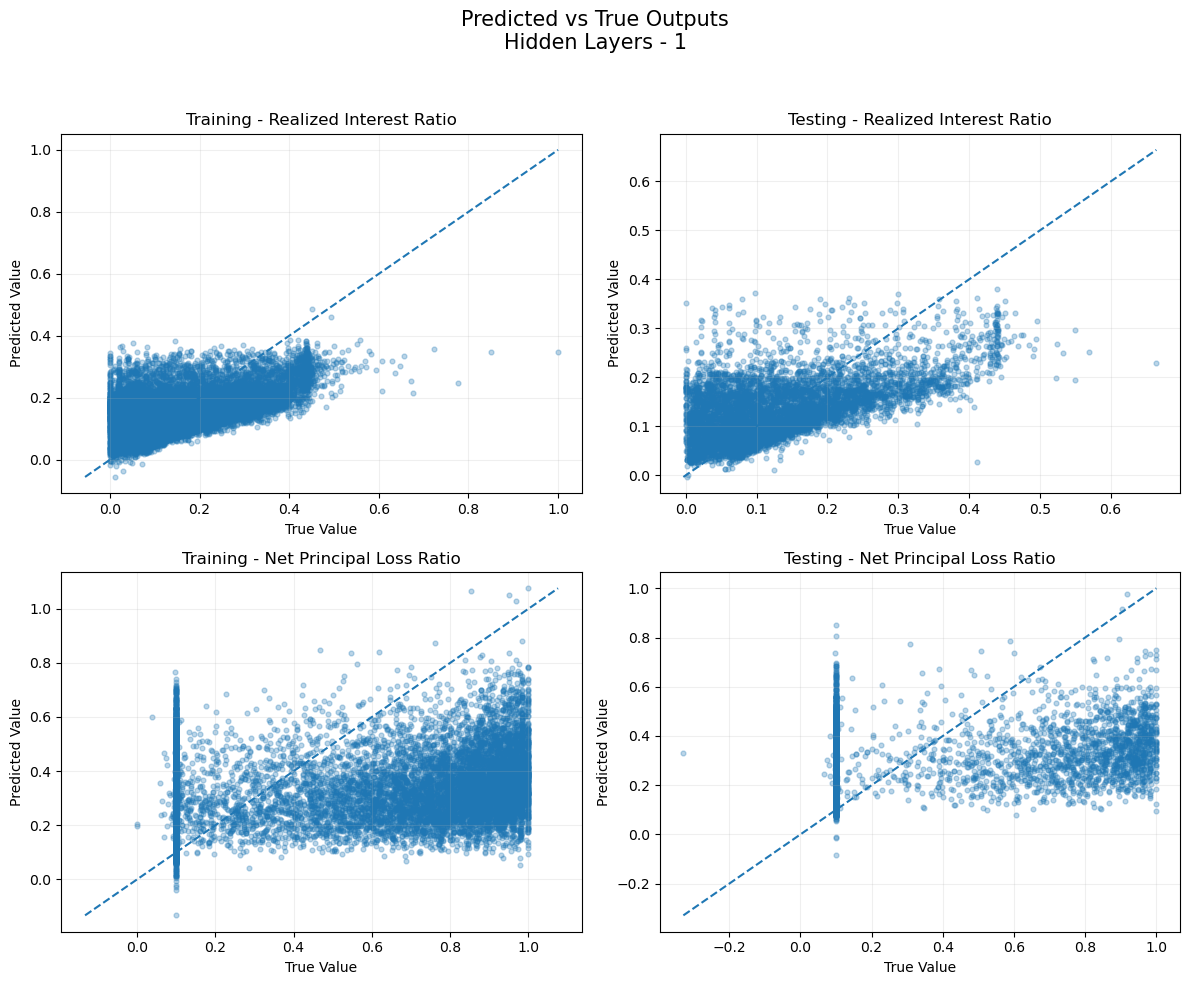


Hidden Layers - 1
Train MSE: 0.04584415
Train R2 : 0.23681650787548558
Test MSE : 0.04722249
Test R2  : 0.2189344404451497


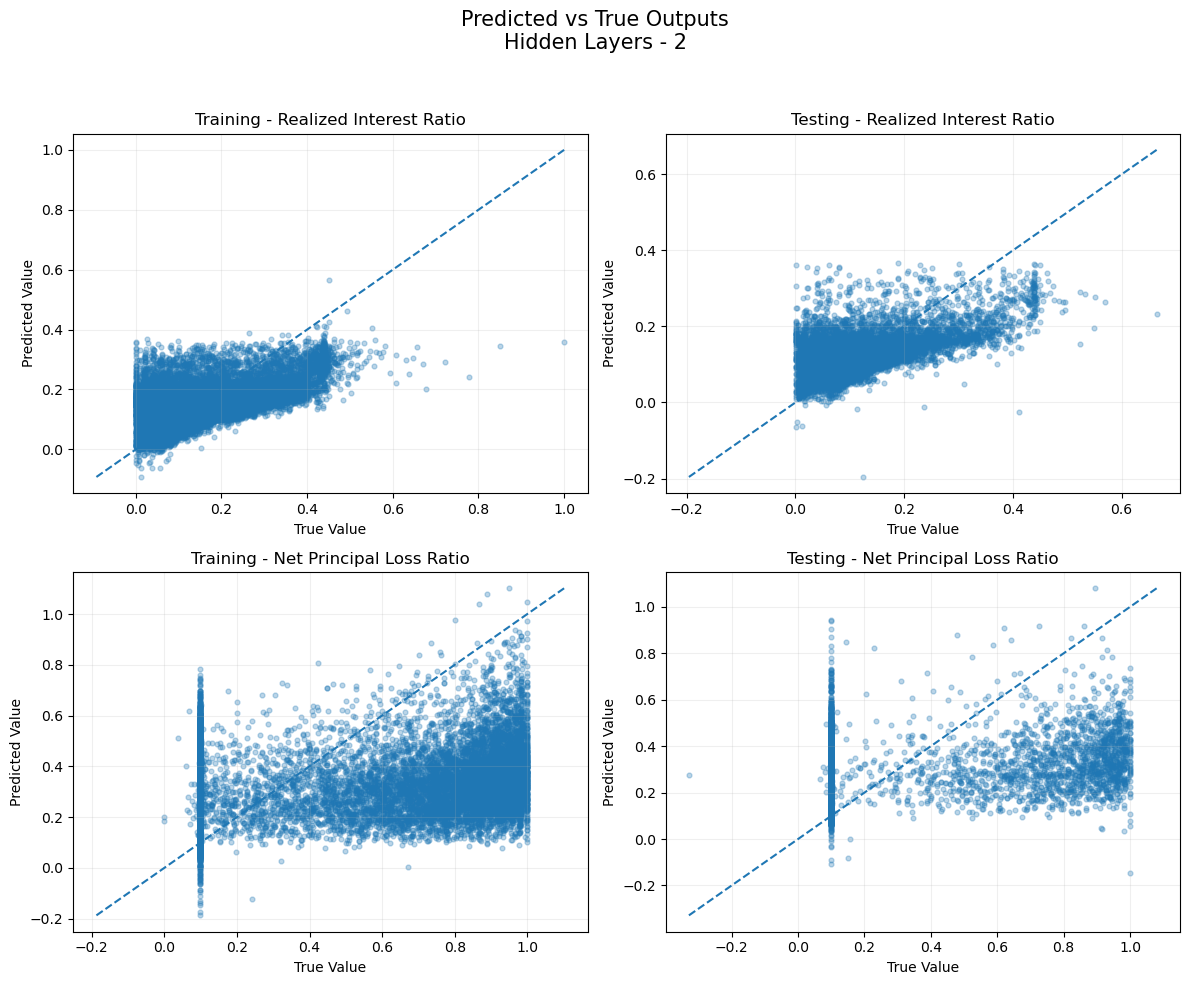


Hidden Layers - 2
Train MSE: 0.045041513
Train R2 : 0.24782178054611553
Test MSE : 0.047930002
Test R2  : 0.20463901227987097


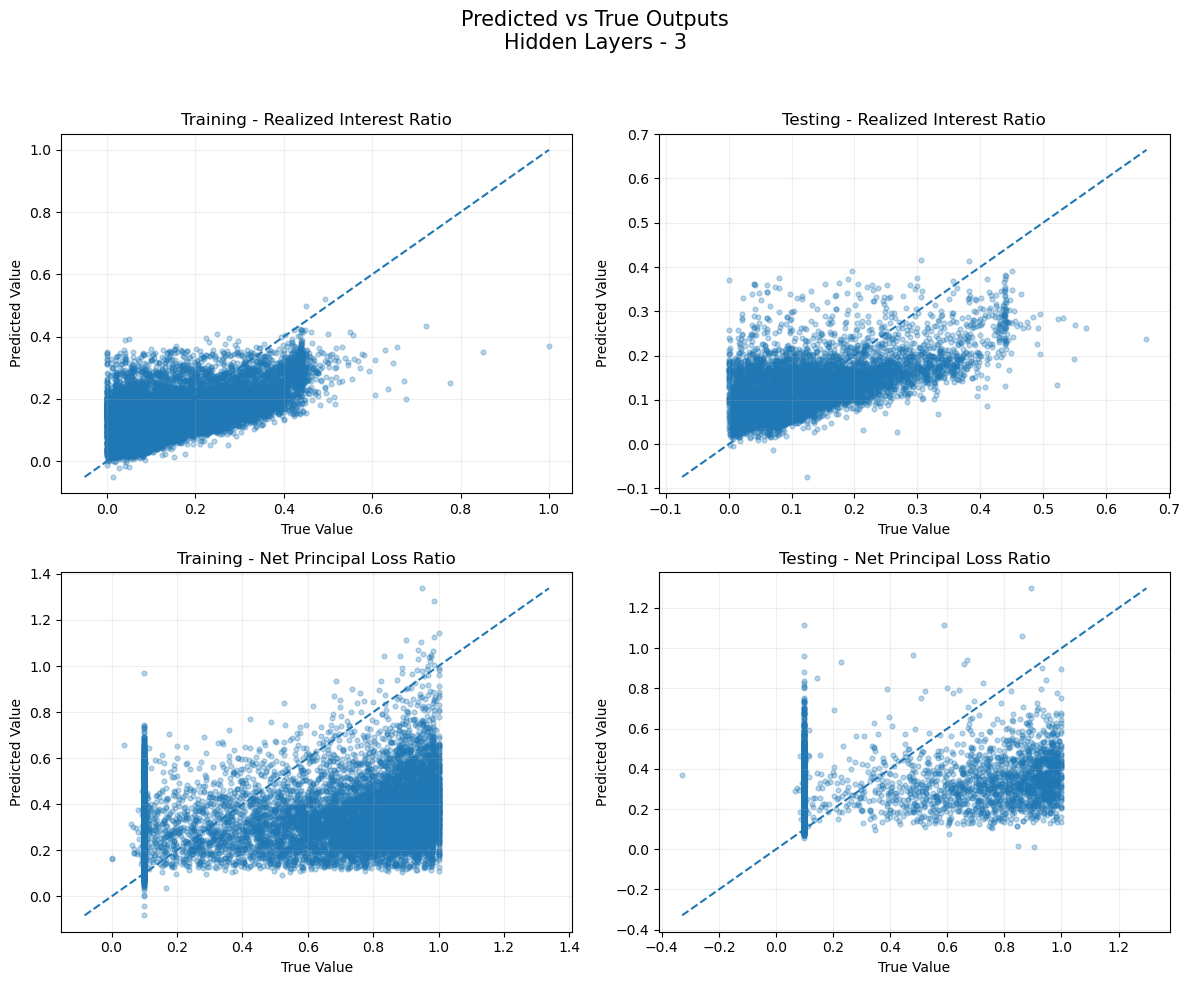


Hidden Layers - 3
Train MSE: 0.044504832
Train R2 : 0.25270861814947476
Test MSE : 0.04792027
Test R2  : 0.20527201974242132


,Experiment,Hidden Layers,Nodes,Activation,Epochs,Sample Fraction,Training Samples,Train MSE Overall,Train R2 Overall,Test MSE Overall,Test R2 Overall,Train MSE Interest,Train R2 Interest,Test MSE Interest,Test R2 Interest,Train MSE Loss,Train R2 Loss,Test MSE Loss,Test R2 Loss
0,Hidden Layers - 1,1,"(64,)",relu,100,1.0,30356,0.045844,0.236817,0.047222,0.218934,0.006854,0.326624,0.006971,0.315643,0.084835,0.147009,0.087474,0.122226
1,Hidden Layers - 2,2,"(64, 32)",relu,100,1.0,30356,0.045042,0.247822,0.047930,0.204639,0.006787,0.333162,0.007135,0.299611,0.083296,0.162481,0.088725,0.109667
2,Hidden Layers - 3,3,"(64, 32, 16)",relu,100,1.0,30356,0.044505,0.252709,0.047920,0.205272,0.006799,0.332028,0.007122,0.300802,0.082211,0.173389,0.088718,0.109742


In [22]:
hidden_layer_results = []

hidden_layer_results.append(
    run_ann_experiment(
        hidden_layers=(64,),
        activation="relu",
        epochs=100,
        sample_fraction=1.0,
        experiment_name="Hidden Layers - 1"
    )
)

hidden_layer_results.append(
    run_ann_experiment(
        hidden_layers=(64, 32),
        activation="relu",
        epochs=100,
        sample_fraction=1.0,
        experiment_name="Hidden Layers - 2"
    )
)

hidden_layer_results.append(
    run_ann_experiment(
        hidden_layers=(64, 32, 16),
        activation="relu",
        epochs=100,
        sample_fraction=1.0,
        experiment_name="Hidden Layers - 3"
    )
)

hidden_layer_df = pd.DataFrame(hidden_layer_results)

hidden_layer_df

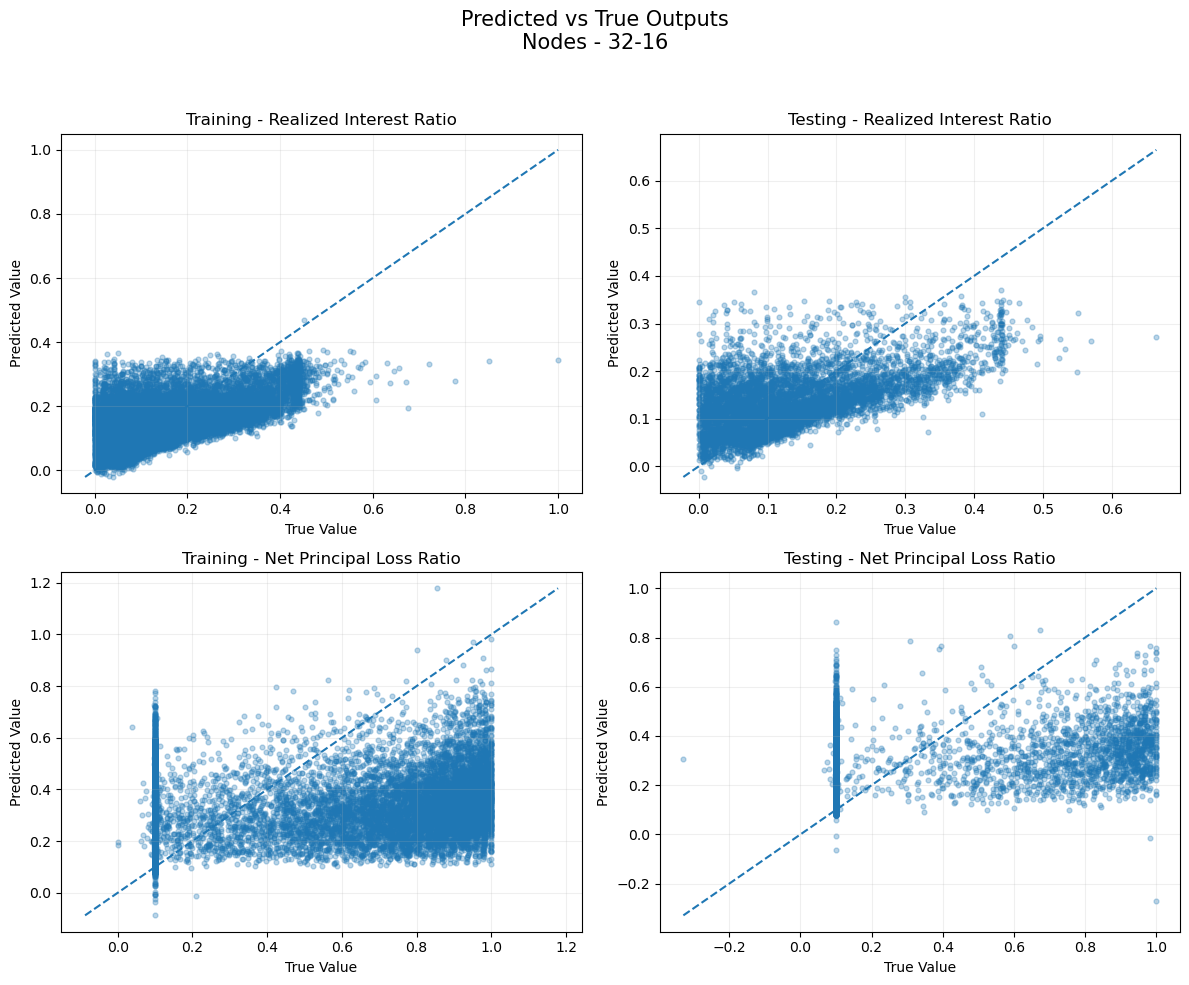


Nodes - 32-16
Train MSE: 0.0460896
Train R2 : 0.23066847196303908
Test MSE : 0.047348045
Test R2  : 0.21181747860767286


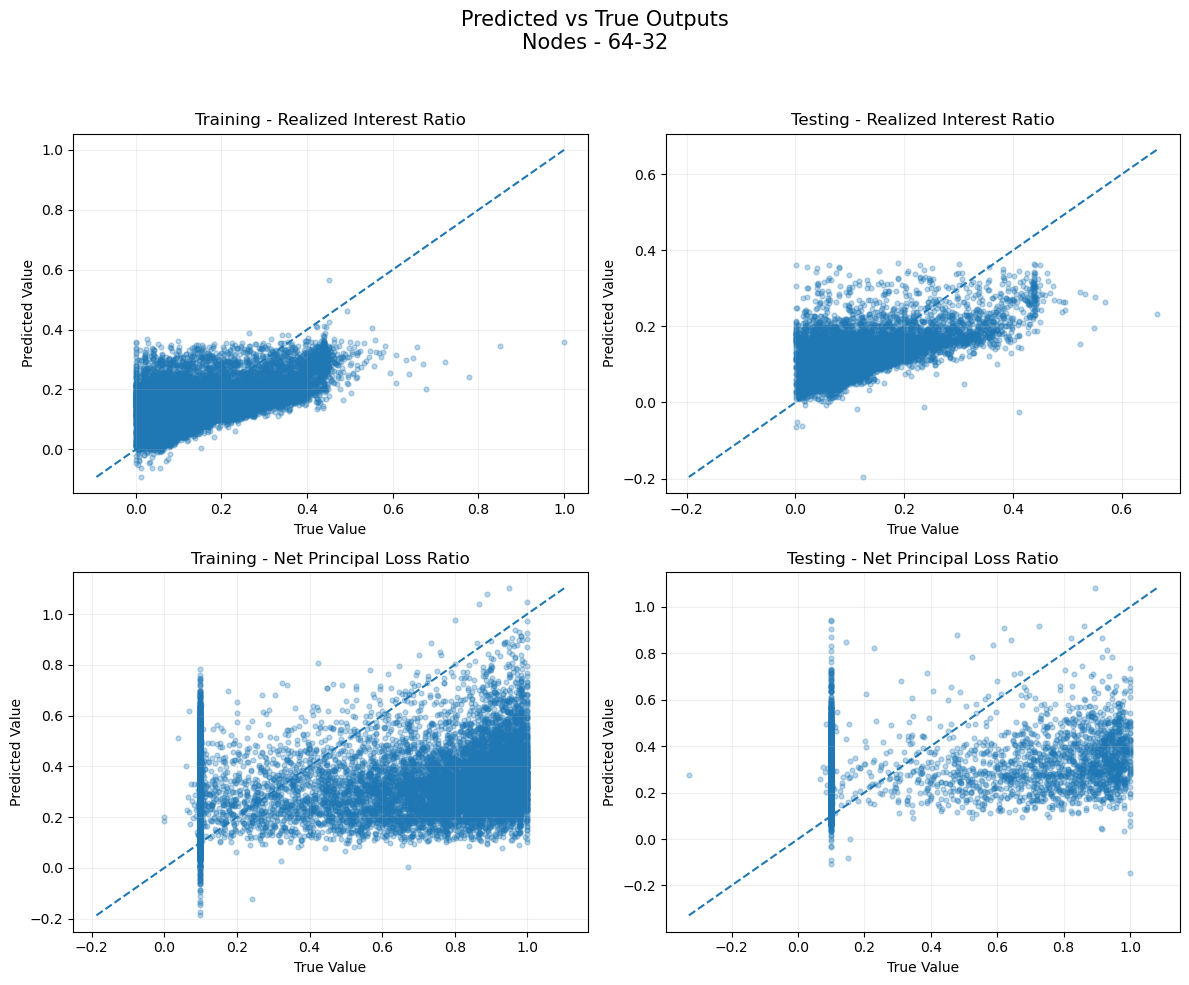


Nodes - 64-32
Train MSE: 0.045041513
Train R2 : 0.24782178054611553
Test MSE : 0.047930002
Test R2  : 0.20463901227987097


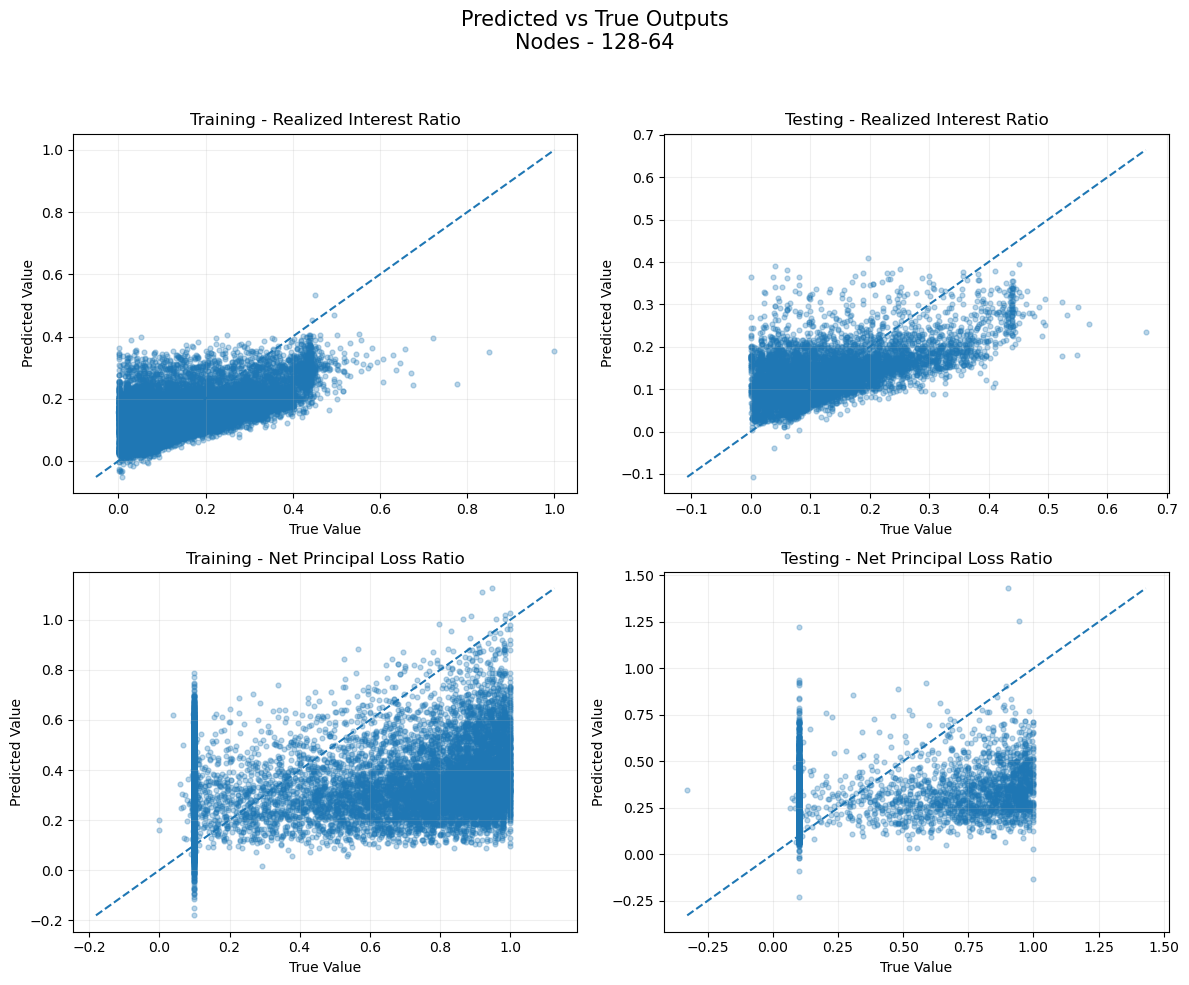


Nodes - 128-64
Train MSE: 0.04409006
Train R2 : 0.26261061104354
Test MSE : 0.048345733
Test R2  : 0.20515343349548337


,Experiment,Hidden Layers,Nodes,Activation,Epochs,Sample Fraction,Training Samples,Train MSE Overall,Train R2 Overall,Test MSE Overall,Test R2 Overall,Train MSE Interest,Train R2 Interest,Test MSE Interest,Test R2 Interest,Train MSE Loss,Train R2 Loss,Test MSE Loss,Test R2 Loss
0,Nodes - 32-16,2,"(32, 16)",relu,100,1.0,30356,0.046090,0.230668,0.047348,0.211817,0.006937,0.318422,0.007104,0.302592,0.085242,0.142915,0.087592,0.121043
1,Nodes - 64-32,2,"(64, 32)",relu,100,1.0,30356,0.045042,0.247822,0.047930,0.204639,0.006787,0.333162,0.007135,0.299611,0.083296,0.162481,0.088725,0.109667
2,Nodes - 128-64,2,"(128, 64)",relu,100,1.0,30356,0.044090,0.262611,0.048346,0.205153,0.006669,0.344797,0.007028,0.310054,0.081512,0.180424,0.089664,0.100253


In [25]:
node_results = []

node_results.append(
    run_ann_experiment(
        hidden_layers=(32, 16),
        activation="relu",
        epochs=100,
        sample_fraction=1.0,
        experiment_name="Nodes - 32-16"
    )
)

node_results.append(
    run_ann_experiment(
        hidden_layers=(64, 32),
        activation="relu",
        epochs=100,
        sample_fraction=1.0,
        experiment_name="Nodes - 64-32"
    )
)

node_results.append(
    run_ann_experiment(
        hidden_layers=(128, 64),
        activation="relu",
        epochs=100,
        sample_fraction=1.0,
        experiment_name="Nodes - 128-64"
    )
)

node_results_df = pd.DataFrame(node_results)

node_results_df

In [ ]:
activation_results = []

for activation_function in [
    "relu",
    "tanh",
    "sigmoid"
]:
    
    result = run_ann_experiment(
        hidden_layers=(64, 32),
        activation=activation_function,
        epochs=100,
        sample_fraction=1.0,
        experiment_name=f"Activation - {activation_function}"
    )
    
    activation_results.append(result)

activation_results_df = pd.DataFrame(
    activation_results
)

activation_results_df

In [ ]:
epoch_results = []

for epoch_value in [
    25,
    50,
    100
]:
    
    result = run_ann_experiment(
        hidden_layers=(64, 32),
        activation="relu",
        epochs=epoch_value,
        sample_fraction=1.0,
        experiment_name=f"Epochs - {epoch_value}"
    )
    
    epoch_results.append(result)

epoch_results_df = pd.DataFrame(
    epoch_results
)

epoch_results_df

In [ ]:
sample_results = []

for fraction in [
    0.25,
    0.50,
    0.75
]:
    
    percentage = int(
        fraction * 100
    )
    
    result = run_ann_experiment(
        hidden_layers=(64, 32),
        activation="relu",
        epochs=100,
        sample_fraction=fraction,
        experiment_name=f"Training Data - {percentage}%"
    )
    
    sample_results.append(result)

sample_results_df = pd.DataFrame(
    sample_results
)

sample_results_df

In [ ]:
all_results = pd.concat(
    [
        hidden_layer_df,
        node_results_df,
        activation_results_df,
        epoch_results_df,
        sample_results_df
    ],
    ignore_index=True
)

all_results

In [ ]:
with pd.ExcelWriter(
    "Point8_ANN_Parameter_Analysis.xlsx"
) as writer:
    
    hidden_layer_df.to_excel(
        writer,
        sheet_name="Hidden Layers",
        index=False
    )
    
    node_results_df.to_excel(
        writer,
        sheet_name="Hidden Nodes",
        index=False
    )
    
    activation_results_df.to_excel(
        writer,
        sheet_name="Activations",
        index=False
    )
    
    epoch_results_df.to_excel(
        writer,
        sheet_name="Epochs",
        index=False
    )
    
    sample_results_df.to_excel(
        writer,
        sheet_name="Sample Size",
        index=False
    )
    
    all_results.to_excel(
        writer,
        sheet_name="All Experiments",
        index=False
    )

print("All results saved successfully.")